#### TFM JESÚS FERRÁNDEZ BERNABEU

Lectura DataSet

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# xls = pd.ExcelFile("DatosGenerados_Final.xlsx")     
xls = pd.ExcelFile("Modelo_Datos_TFM_Estrella_Final.xlsx")
print(xls.sheet_names)

dim_grupo    = pd.read_excel(xls, "DimGrupo")
fact_ventas  = pd.read_excel(xls, "FactVentas")
dim_fecha    = pd.read_excel(xls, "DimFecha", parse_dates=["fecha"])
dim_producto = pd.read_excel(xls, "DimProducto")
dim_local    = pd.read_excel(xls, "DimLocal")

for n, df in [("DimGrupo", dim_grupo), ("FactVentas", fact_ventas),
              ("DimFecha", dim_fecha), ("DimProducto", dim_producto),
              ("DimLocal", dim_local)]:
    print(n, df.shape)

fact_ventas.head()

['DimGrupo', 'FactVentas', 'DimFecha', 'DimProducto', 'DimLocal']
DimGrupo (286, 5)
FactVentas (553, 7)
DimFecha (12, 9)
DimProducto (47, 5)
DimLocal (5, 3)


,id_linea,id_producto,id_grupo,id_fecha,id_local,cantidad,precio_descuento
0,1,103,999,20260522,3,3,0
1,2,103,998,20260522,3,1,0
2,3,103,997,20260522,3,5,0
3,4,103,996,20260522,3,4,0
4,5,103,995,20260522,3,1,0


Se genera un registro por grupo y dia, y se genera una columna por producto, de manera que se puede ver la cantidad de ese producto que se ha pedido por dicho grupo en dicho dia

In [35]:
# Matriz cesta x producto (cantidades)
cestas = (
    fact_ventas
    .pivot_table(
        index=["id_grupo", "id_fecha"],
        columns="id_producto",
        values="cantidad",
        aggfunc="sum",     # suma si el mismo producto aparece en varias líneas
        fill_value=0
    )
    .reset_index()
)

cestas.columns.name = None      # quita el nombre 'id_producto' del eje de columnas
print(cestas.shape)
cestas.head()

(286, 31)


,id_grupo,id_fecha,100,101,103,105,109,110,111,112,...,126,130,131,132,133,134,143,145,146,147
0,714,20260620,0,0,0,0,0,0,0,0,...,0,0,0,5,0,0,0,0,0,0
1,715,20260620,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2,716,20260620,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,717,20260620,0,0,0,0,0,0,0,0,...,0,2,0,0,4,0,0,0,0,0
4,718,20260620,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


Se cambia el nombre de cada columna por el nombre del producto y el indicador del local

In [36]:
mapa = dim_producto.assign(
    etiqueta=dim_producto["nombre"] + "_L" + dim_producto["id_local"].astype(str)
).set_index("id_producto")["etiqueta"]

cestas_nom = cestas.rename(columns=mapa)

In [37]:
prod_cols = [c for c in cestas.columns if c not in ("id_grupo", "id_fecha")]
cestas_bin = cestas.copy()
cestas_bin[prod_cols] = (cestas_bin[prod_cols] > 0).astype(int)

In [38]:
cestas_nom.head()

,id_grupo,id_fecha,Croqueta_L3,Fingers pollo casero + salsa Java_L3,Hamburguesa_L3,Entrecote Premium_L3,Ensaladilla (alias cod. 110)_L2,Ensaladilla_L2,Variado de ensaladillas_L2,Marinera_L2,...,Bocadillos_L2,Bola de helado_L1,Mochi_L1,Tarta_L1,Granizado_L1,Polo_L1,Nachos_L4,Nuggets_L4,Pizza_L4,Porción de pizza_L4
0,714,20260620,0,0,0,0,0,0,0,0,...,0,0,0,5,0,0,0,0,0,0
1,715,20260620,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2,716,20260620,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,717,20260620,0,0,0,0,0,0,0,0,...,0,2,0,0,4,0,0,0,0,0
4,718,20260620,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


Eliminamos productos sin ventas

In [39]:
# ---------- Detección y eliminación de productos sin ventas ----------
ID_COLS = ["id_grupo", "id_fecha"]   # columnas que NO son producto

def columnas_producto(df, id_cols=ID_COLS):
    """Devuelve las columnas de producto (todas menos las identificadoras)."""
    return [c for c in df.columns if c not in id_cols]


def productos_sin_ventas(df, id_cols=ID_COLS, catalogo=None, col_id="id_producto"):
    """
    Productos con 0 ventas. Cubre los dos casos:
      1) columnas presentes en df cuya suma total es 0
      2) productos del catálogo (DimProducto) que nunca llegaron a ser columna
    """
    prod = columnas_producto(df, id_cols)
    suma = df[prod].sum()
    vacias = suma[suma == 0].index.tolist()

    ausentes = []
    if catalogo is not None:
        ausentes = [p for p in catalogo[col_id] if p not in prod]

    return {"columnas_a_cero": vacias, "nunca_vendidos": ausentes}


def eliminar_sin_ventas(df, id_cols=ID_COLS, verbose=True):
    """Devuelve una copia de df sin las columnas de producto que suman 0."""
    prod = columnas_producto(df, id_cols)
    suma = df[prod].sum()
    a_borrar = suma[suma == 0].index.tolist()

    if verbose:
        print(f"Columnas de producto: {len(prod)}")
        print(f"Sin ventas ({len(a_borrar)}): {a_borrar}")
        print(f"Se conservan: {len(prod) - len(a_borrar)}")

    return df.drop(columns=a_borrar)


# ----------- USO --------------
# Diagnóstico
info = productos_sin_ventas(cestas_bin, catalogo=dim_producto)
print("Columnas a cero  :", info["columnas_a_cero"])
print("Nunca vendidos   :", info["nunca_vendidos"])

# Limpieza
cestas_bin = eliminar_sin_ventas(cestas_bin)
cestas     = eliminar_sin_ventas(cestas, verbose=False)   # misma limpieza en cantidades

Columnas a cero  : []
Nunca vendidos   : [102, 104, 106, 121, 122, 135, 140, 141, 142, 144, 150, 151, 152, 153, 154, 155, 156, 157]
Columnas de producto: 29
Sin ventas (0): []
Se conservan: 29


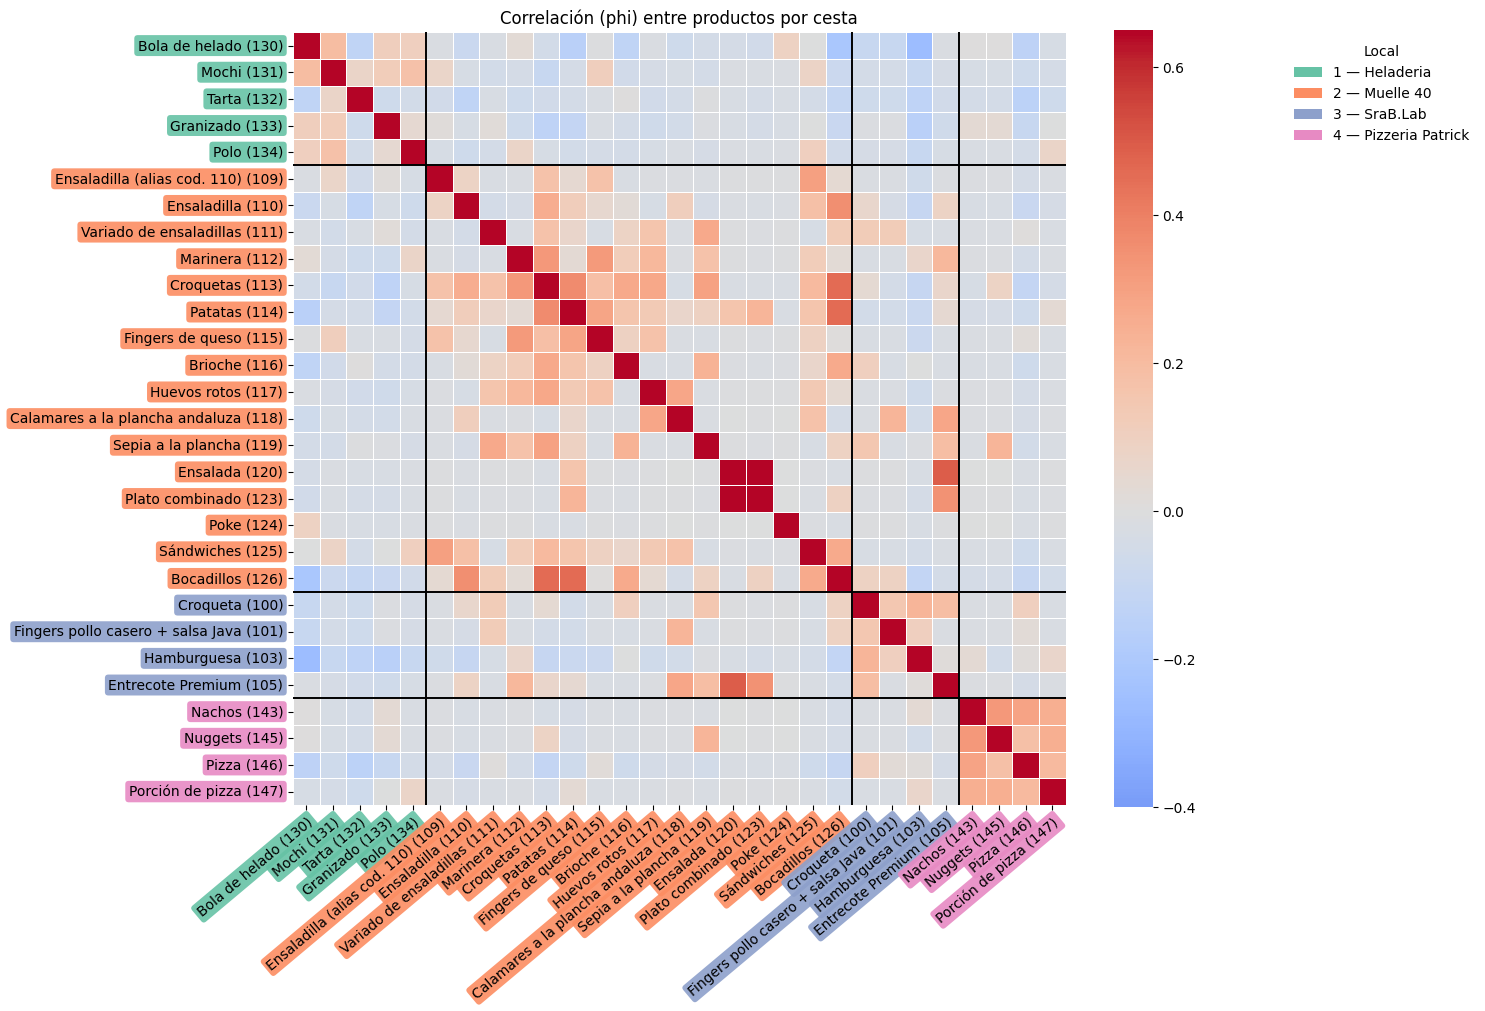

In [45]:
from matplotlib.patches import Patch

ID_COLS = ["id_grupo", "id_fecha"]
prod_cols = [c for c in cestas_bin.columns if c not in ID_COLS]

info_prod = dim_producto.set_index("id_producto")

# Ordenar productos por local (agrupa los bloques visualmente)
orden = sorted(prod_cols, key=lambda p: (info_prod["id_local"].get(p, 9999), p))

matriz_corr = cestas_bin[orden].corr()

# Local de cada producto y paleta de colores
locales_ord    = [info_prod["id_local"].get(p, None) for p in orden]
locales_unicos = sorted({l for l in locales_ord if l is not None})
paleta         = dict(zip(locales_unicos, sns.color_palette("Set2", len(locales_unicos))))
colores_tick   = [paleta.get(l, (.8, .8, .8)) for l in locales_ord]   # gris si no tiene local

# Etiquetas legibles (nombre + id, evita ambigüedad si hay nombres repetidos)
etiquetas = [f'{info_prod["nombre"].get(p, p)} ({p})' for p in orden]
matriz_corr.index = etiquetas
matriz_corr.columns = etiquetas

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(matriz_corr, cmap="coolwarm", center=0, vmin=-0.4, vmax=0.65,
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, ax=ax)

# Fondo de color en las etiquetas de ambos ejes
for tick, color in zip(ax.get_xticklabels(), colores_tick):
    tick.set_bbox(dict(facecolor=color, edgecolor="none", boxstyle="round,pad=0.25", alpha=.9))
    tick.set_rotation(40)
    tick.set_ha("right")                  # alinea el final del texto con la celda
    tick.set_rotation_mode("anchor")      # evita que se descoloquen al rotar
for tick, color in zip(ax.get_yticklabels(), colores_tick):
    tick.set_bbox(dict(facecolor=color, edgecolor="none", boxstyle="round,pad=0.25", alpha=.9))

cortes = [i for i in range(1, len(locales_ord)) if locales_ord[i] != locales_ord[i-1]]
for c in cortes:
    ax.axhline(c, color="black", lw=1.4)
    ax.axvline(c, color="black", lw=1.4)

# Leyenda
nom_local = (dim_local.set_index("id_local")["nombre_local"].to_dict()
             if "nombre_local" in dim_local.columns else {})
handles = [Patch(facecolor=paleta[l], label=f"{l} — {nom_local.get(l, '')}") for l in locales_unicos]
ax.legend(handles=handles, title="Local", bbox_to_anchor=(1.28, 1), loc="upper left", frameon=False)

plt.title("Correlación (phi) entre productos por cesta")
plt.tight_layout()
plt.show()

In [41]:
pares = (matriz_corr
         .where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))  # solo triángulo superior
         .stack()
         .sort_values(ascending=False)
         .rename("correlacion")
         .reset_index())
pares.columns = ["producto_A", "producto_B", "correlacion"]

pares.head(20)

,producto_A,producto_B,correlacion
0,Ensalada (120),Plato combinado (123),0.705865
1,Ensalada (120),Entrecote Premium (105),0.497361
2,Patatas (114),Bocadillos (126),0.460070
3,Croquetas (113),Bocadillos (126),0.457946
4,Croquetas (113),Patatas (114),0.364379
5,Ensaladilla (110),Bocadillos (126),0.357347
6,Plato combinado (123),Entrecote Premium (105),0.347309
7,Marinera (112),Croquetas (113),0.329023
8,Nachos (143),Nuggets (145),0.326266
9,Marinera (112),Fingers de queso (115),0.324179
